<div align="right">
АС-23-05, Тищенко Кирилл, Вариант №97
</div>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib import cm
from scipy.optimize import minimize
from scipy.optimize import minimize_scalar
from mpl_toolkits.mplot3d import Axes3D

# Лабораторная работа №4 "Методы многомерной минимизации"

$$f(\mathbf{x}) = 194x_1^2 + 376x_1x_2 + 194x_2^2 + 31x_1 - 229x_2 + 4$$

In [9]:
def f(x):
    x1, x2 = x
    return 194 * x1 ** 2 + 376 * x1 * x2 + 194 * x2 ** 2 + 31 * x1 - 229 * x2 + 4

In [10]:
def grad_f(x):
    x1, x2 = x
    df_dx1 = 388 * x1 + 376 * x2 + 31
    df_dx2 = 376 * x1 + 388 * x2 - 229
    return np.array([df_dx1, df_dx2])

In [11]:
def hess_f(x):
    return np.array([
        [388, 376],
        [376, 388]
    ])

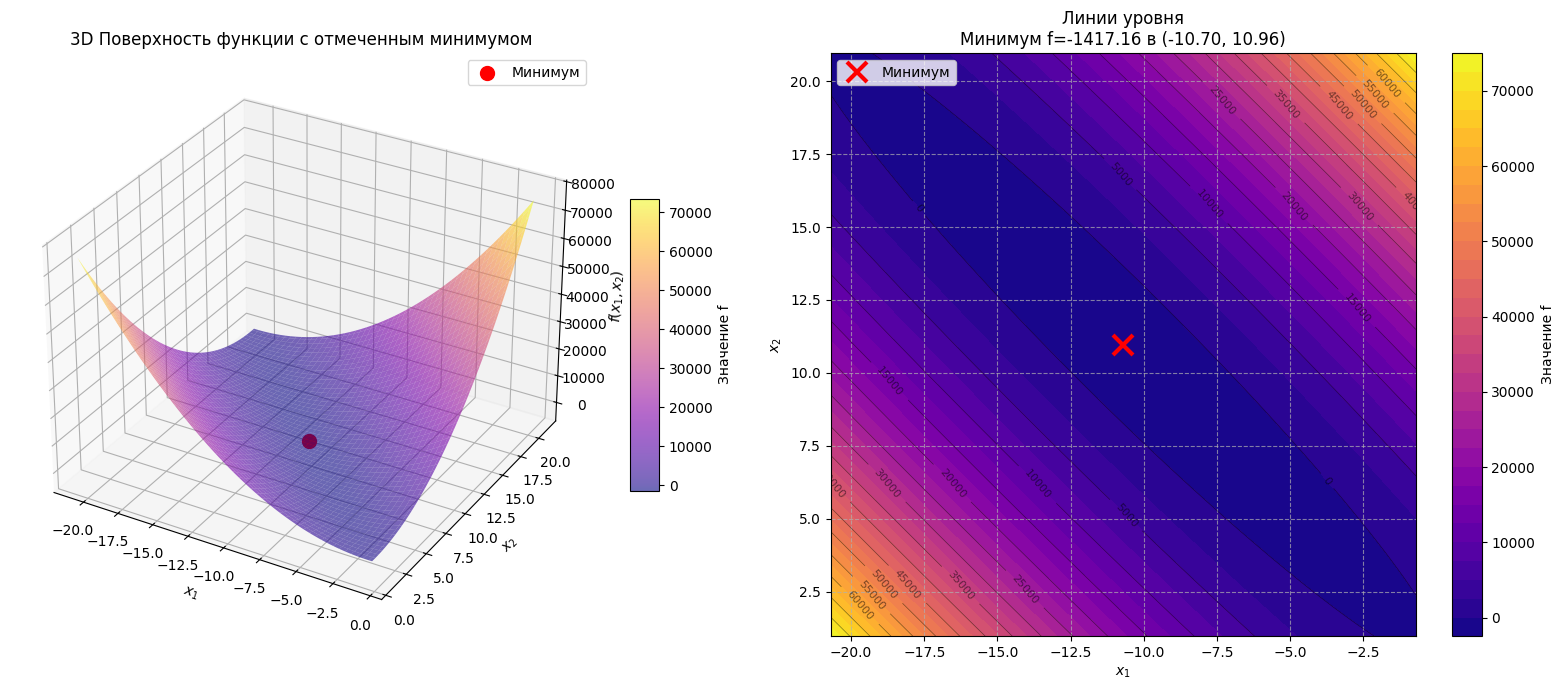

Точка минимума
x1 = -10.70
x2 = 10.96
Значение функции в этой точке: -1417.16


In [6]:
x_min_arr = np.array([-10.7037581, 10.96292084])
f_min_val = -1417.1618673642563

buffer = 10
x1_range = np.linspace(x_min_arr[0] - buffer, x_min_arr[0] + buffer, 100)
x2_range = np.linspace(x_min_arr[1] - buffer, x_min_arr[1] + buffer, 100)

X1, X2 = np.meshgrid(x1_range, x2_range)

def f_mesh(x1, x2):
    return 194*x1**2 + 376*x1*x2 + 194*x2**2 + 31*x1 - 229*x2 + 4

Z = f_mesh(X1, X2)


fig = plt.figure(figsize=(16, 7))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(X1, X2, Z, cmap='plasma', edgecolor='none', alpha=0.6)
ax1.scatter(x_min_arr[0], x_min_arr[1], f_min_val, color='red', s=100, label='Минимум')
ax1.set_title('3D Поверхность функции с отмеченным минимумом')
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_zlabel('$f(x_1, x_2)$')
ax1.legend()
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10, label='Значение f')


ax2 = fig.add_subplot(1, 2, 2)
contour_filled = ax2.contourf(X1, X2, Z, levels=30, cmap='plasma')
fig.colorbar(contour_filled, ax=ax2, label='Значение f')
contours = ax2.contour(X1, X2, Z, levels=15, colors='black', alpha=0.5, linewidths=0.5)
ax2.clabel(contours, inline=True, fontsize=8)
ax2.plot(x_min_arr[0], x_min_arr[1], 'rx', markersize=15, markeredgewidth=3, label='Минимум')

ax2.set_title(f'Линии уровня\nМинимум f={f_min_val:.2f} в ({x_min_arr[0]:.2f}, {x_min_arr[1]:.2f})')
ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

x0 = [0, 0]
res = minimize(f, x0, method='BFGS')

print(f"Точка минимума\nx1 = {res.x[0]:.2f}\nx2 = {res.x[1]:.2f}")
print(f"Значение функции в этой точке: {res.fun:.2f}")

## 1. Метод наискорейшего спуска

In [29]:
def steepest_descent(f, grad_f, hess_f, x0, tol=1e-2, max_iter=5000):
    x = x0.copy()
    iter_count = 0
    f_calls = 0
    grad_calls = 0
    
    def f_counted(x):
        nonlocal f_calls
        f_calls += 1
        return f(x)
    
    def grad_counted(x):
        nonlocal grad_calls
        grad_calls += 1
        return grad_f(x)
    for k in range(max_iter):
        g = grad_counted(x)
        if np.linalg.norm(g) < tol:
            break
        alpha = 1.0
        for _ in range(20):
            x_alpha = x - alpha * g
            grad_alpha = grad_counted(x_alpha)
            H_alpha = hess_f(x_alpha)
            
            phi_prime = -np.dot(grad_alpha, g)
            phi_double_prime = np.dot(g, H_alpha @ g)
            if abs(phi_double_prime) < 1e-8:
                break
            alpha_new = alpha - phi_prime / phi_double_prime
            if abs(alpha_new - alpha) < 1e-6:
                alpha = alpha_new
                break
            alpha = alpha_new
        x = x - alpha * g
        iter_count += 1
    
    return x, f(x), iter_count, f_calls, grad_calls - 1

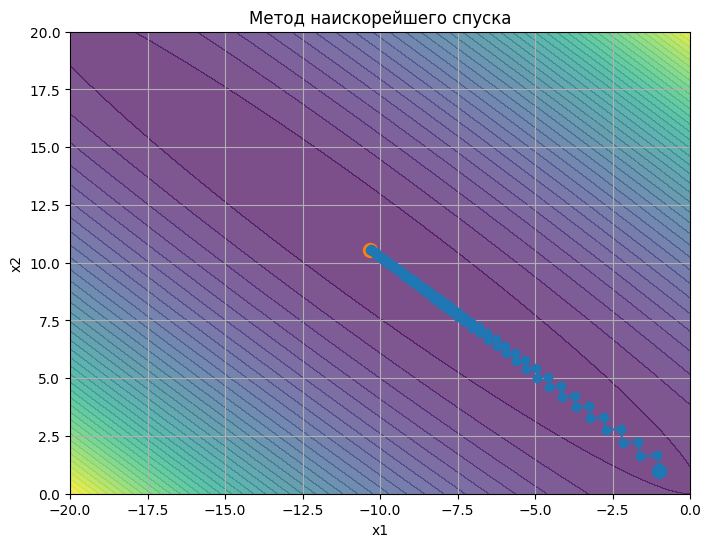

Точка минимума
x1 = -10.70
x2 = 10.96
Значение функции в этой точке: -1417.16
Число итераций: 310
Число вычислений функции: 0
Число вычислений градиента функции: 930


In [30]:
def steepest_descent_path(f, grad_f, x0, tol=1e-2, max_iter=100):
    x = x0.copy()
    path = [x.copy()]
    for _ in range(max_iter):
        grad = grad_f(x)
        if np.linalg.norm(grad) < tol:
            break
        phi = lambda alpha: f(x - alpha * grad)
        alpha = minimize_scalar(phi).x
        x = x - alpha * grad
        path.append(x.copy())
    return np.array(path)
    
x0 = np.array([-1.0, 1.0])
path = steepest_descent_path(f, grad_f, x0)
x1 = np.linspace(-20, 0, 200)
x2 = np.linspace(20, 0, 200)
X1, X2 = np.meshgrid(x1, x2)
Z = 194 * X1**2 + 376 * X1 * X2 + 194 * X2**2 + 31 * X1 - 229 * X2 + 4

plt.figure(figsize=(8, 6))
cp = plt.contourf(X1, X2, Z, levels=50, cmap='viridis', alpha=0.7)
plt.plot(path[:, 0], path[:, 1], 'o-')
plt.scatter(path[0, 0], path[0, 1], s=100)
plt.scatter(path[-1, 0], path[-1, 1], s=100)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Метод наискорейшего спуска")
plt.grid()
plt.show()

answer = steepest_descent(f, grad_f, hess_f, x0)
print(f"Точка минимума\nx1 = {answer[0][0]:.2f}\nx2 = {answer[0][1]:.2f}")
print(f"Значение функции в этой точке: {answer[1]:.2f}")
print(f"Число итераций: {int(answer[2])}")
print(f"Число вычислений функции: {int(answer[3])}")
print(f"Число вычислений градиента функции: {int(answer[4])}")

## 2. Метод Марквардта

In [12]:
def marquardt(f, grad_f, hess_f, x0, tol=1e-2, max_iter=5000):
    x = x0.copy()
    lam = 1.0
    iter_count = 0
    f_calls = 0
    grad_calls = 0
    hess_calls = 0
    
    def f_counted(x):
        nonlocal f_calls
        f_calls += 1
        return f(x)
    
    def grad_counted(x):
        nonlocal grad_calls
        grad_calls += 1
        return grad_f(x)
    
    def hess_counted(x):
        nonlocal hess_calls
        hess_calls += 1
        return hess_f(x)
    
    for _ in range(max_iter):
        g = grad_counted(x)
        if np.linalg.norm(g) < tol:
            break
        H = hess_counted(x)
        n = len(x)
        H_lm = H + lam * np.eye(n)
        try:
            p = -np.linalg.solve(H_lm, g)
        except np.linalg.LinAlgError:
            lam *= 10
            continue
        x_new = x + p
        if f_counted(x_new) < f_counted(x):
            x = x_new
            lam *= 0.7
            iter_count += 1
        else:
            lam *= 2.0
    
    return x, f(x), iter_count, f_calls, grad_calls - 1

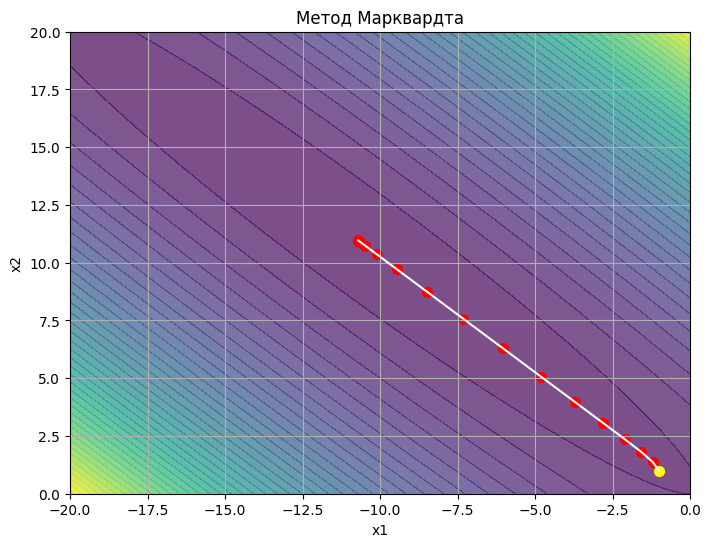

Точка минимума
x1 = -10.70
x2 = 10.96
Значение функции в этой точке: -1417.16
Число итераций: 4
Число вычислений функции: 8
Число вычислений градиента функции: 4


In [13]:
def marquardt_path(x0, tol=1e-2, max_iter=100):
    x = x0.copy()
    lam = 388.0
    path = [x.copy()]
    for _ in range(max_iter):
        g = grad_f(x)
        if np.linalg.norm(g) < tol:
            break
        H = hess_f(x)
        H_lm = H + lam * np.eye(len(x))
        try:
            p = -np.linalg.solve(H_lm, g)
        except np.linalg.LinAlgError:
            lam *= 10
            continue
        x_new = x + p
        if f(x_new) < f(x):
            x = x_new
            lam *= 0.7
            path.append(x.copy())
        else:
            lam *= 2.0
    return np.array(path)

x0 = np.array([-1.0, 1.0])
path_mq = marquardt_path(x0)
x1 = np.linspace(-20, 0, 200)
x2 = np.linspace(0, 20, 200)
X1, X2 = np.meshgrid(x1, x2)
Z = 194 * X1**2 + 376 * X1 * X2 + 194 * X2**2 + 31 * X1 - 229 * X2 + 4

plt.figure(figsize=(8, 6))
cp = plt.contourf(X1, X2, Z, levels=50, cmap='viridis', alpha=0.7)
plt.plot(path_mq[:, 0], path_mq[:, 1], 'w-', label='Траектория')
plt.scatter(path_mq[:, 0], path_mq[:, 1], c='red', s=50)
plt.scatter(x0[0], x0[1], c='yellow', s=50)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Метод Марквардта")
plt.grid()
plt.show()

answer = marquardt(f, grad_f, hess_f, x0)
print(f"Точка минимума\nx1 = {answer[0][0]:.2f}\nx2 = {answer[0][1]:.2f}")
print(f"Значение функции в этой точке: {answer[1]:.2f}")
print(f"Число итераций: {int(answer[2])}")
print(f"Число вычислений функции: {int(answer[3])}")
print(f"Число вычислений градиента функции: {int(answer[4])}")

| Параметр | x1 | x2 | f(x1, x2) | Число итераций | Число вычислений функции | Число вычислений градиента функции |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Пакетный метод BFGS** | -10.70 | 10.96 | -1417.16 | - | - | - |
| **Метод наискорейшего спуска** | -10.70 | 10.96 | -1417.16 | 310 | 0 | 310 |
| **Метод Марквардта** | -10.70 | 10.96 | -1417.16 | 4 | 8 | 4 |

## 3. Оптимизация функции Химмельблау

In [3]:
def f_himmelblau(x):
    x1, x2 = x[0], x[1]
    return 100 * (x1**2 + x2 - 11)**2 + (x1 + x2**2 - 7)**2

In [4]:
def grad_f_himmelblau(x):
    x1, x2 = x[0], x[1]
    
    df_dx1 = 400 * (x1**2 + x2 - 11) * x1 + 2 * (x1 + x2**2 - 7)
    df_dx2 = 200 * (x1**2 + x2 - 11) + 4 * x2 * (x1 + x2**2 - 7)
    
    return np.array([df_dx1, df_dx2])

In [5]:
def hess_f_himmelblau(x):
    x1, x2 = x[0], x[1]
    
    return np.array([[400*(x1**2 + x2 - 11) + 800*x1**2 + 2, 400*x1 + 4*x2], [400*x1 + 4*x2, 200 + 12*x2**2 + 4*(x1 + x2**2 - 7)]])

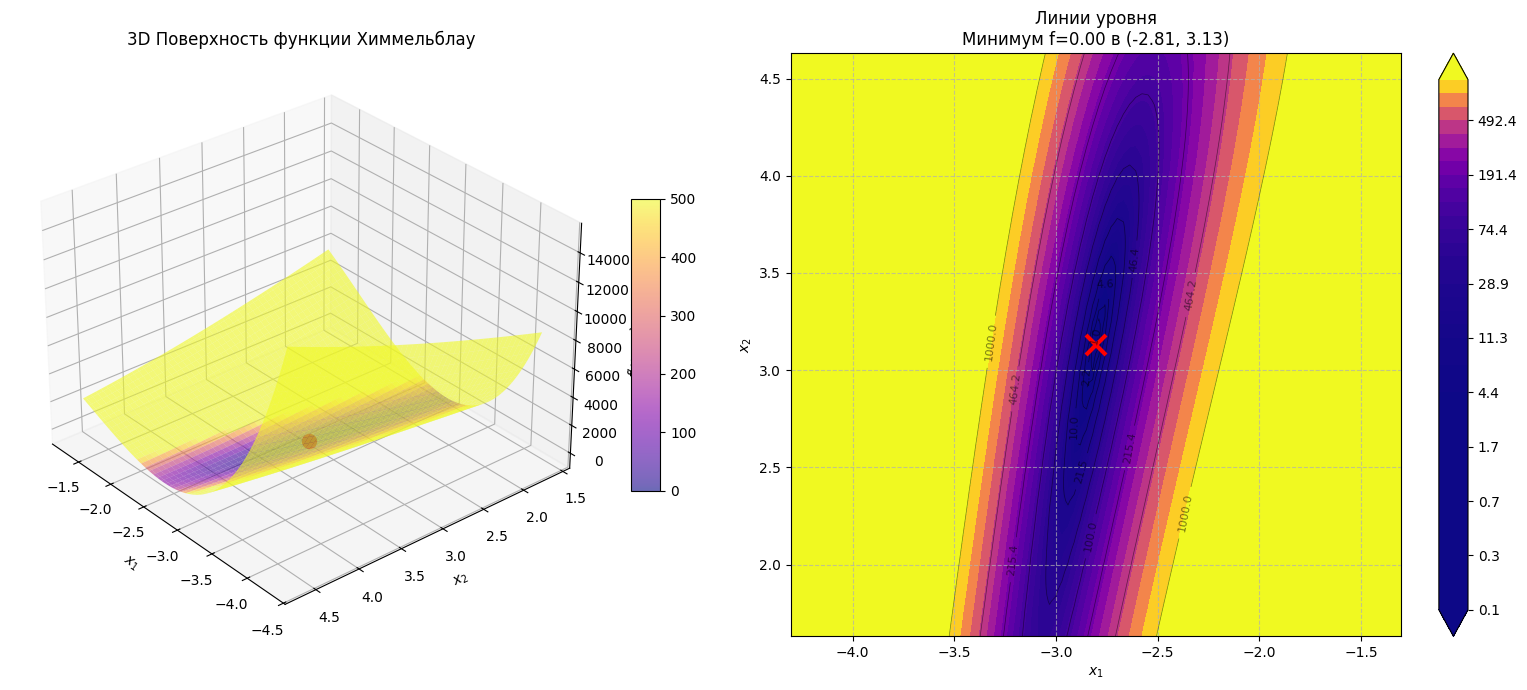

Точка минимума
x1 = -2.81
x2 = 3.13
Значение функции в этой точке: 0.00


In [36]:
x_min_arr = np.array([-2.805, 3.131])
f_min_val = f_himmelblau(x_min_arr)

buffer = 1.5
x1_range = np.linspace(x_min_arr[0] - buffer, x_min_arr[0] + buffer, 100)
x2_range = np.linspace(x_min_arr[1] - buffer, x_min_arr[1] + buffer, 100)
X1, X2 = np.meshgrid(x1_range, x2_range)
Z = f_himmelblau([X1, X2])
fig = plt.figure(figsize=(16, 7))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(X1, X2, Z, cmap='plasma', edgecolor='none', alpha=0.6, 
                        norm=plt.Normalize(vmin=0, vmax=500))
ax1.scatter(x_min_arr[0], x_min_arr[1], f_min_val, color='red', s=100)
ax1.set_title('3D Поверхность функции Химмельблау')
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_zlabel('$f(x_1, x_2)$')
ax1.view_init(elev=30, azim=140)
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)
ax2 = fig.add_subplot(1, 2, 2)
levels = np.logspace(-1, 3, 40) 
contour_filled = ax2.contourf(X1, X2, Z, levels=levels, cmap='plasma', extend='both')
fig.colorbar(contour_filled, ax=ax2) 
contours = ax2.contour(X1, X2, Z, levels=np.logspace(0, 3, 10), colors='black', alpha=0.5, linewidths=0.5)
ax2.clabel(contours, inline=True, fontsize=8)
ax2.plot(x_min_arr[0], x_min_arr[1], 'rx', markersize=15, markeredgewidth=3)
ax2.set_title(f'Линии уровня\nМинимум f={f_min_val:.2f} в ({x_min_arr[0]:.2f}, {x_min_arr[1]:.2f})')
ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

x0 = [-1.2, 1.0]
res = minimize(f_himmelblau, x0, method='BFGS')
print(f"Точка минимума\nx1 = {res.x[0]:.2f}\nx2 = {res.x[1]:.2f}")
print(f"Значение функции в этой точке: {res.fun:.2f}")

## 3.1 Оптимизация функции Химмельблау методом наискорейшего спуска

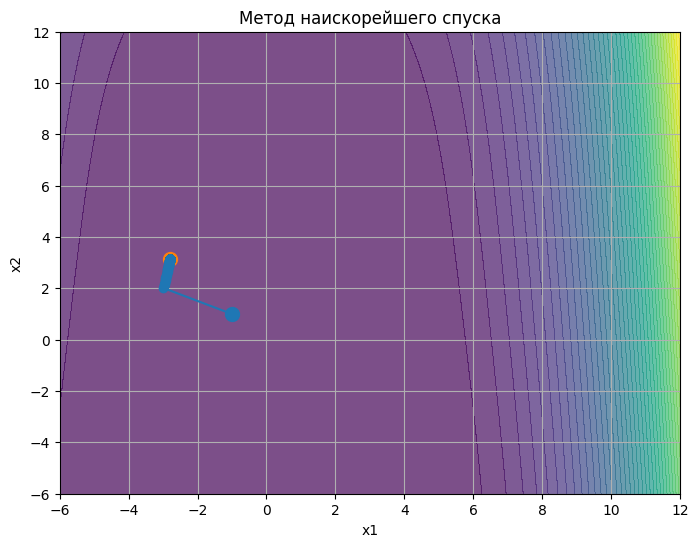

Точка минимума
x1 = -2.81
x2 = 3.13
Значение функции в этой точке: 0.00
Число итераций: 133
Число вычислений функции: 2552
Число вычислений градиента функции: 133


In [28]:
def steepest_descent_path(f_himmelblau, grad_f_himmelblau, x0, tol=1e-4, max_iter=1000):
    x = x0.copy()
    path = [x.copy()]
    for _ in range(max_iter):
        grad = grad_f_himmelblau(x)
        if np.linalg.norm(grad) < tol:
            break
        phi = lambda alpha: f_himmelblau(x - alpha * grad)
        alpha = minimize_scalar(phi).x
        x = x - alpha * grad
        path.append(x.copy())
    
    return np.array(path)

x0 = np.array([-1.0, 1.0])
path = steepest_descent_path(f_himmelblau, grad_f_himmelblau, x0)
x1 = np.linspace(-6, 12, 200)
x2 = np.linspace(-6, 12, 200)
X1, X2 = np.meshgrid(x1, x2)
Z = 100 * (X1**2 + X2 - 11)**2 + (X1 + X2**2 - 7)**2

plt.figure(figsize=(8, 6))
cp = plt.contourf(X1, X2, Z, levels=50, cmap='viridis', alpha=0.7)
plt.plot(path[:, 0], path[:, 1], 'o-')
plt.scatter(path[0, 0], path[0, 1], s=100)
plt.scatter(path[-1, 0], path[-1, 1], s=100)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Метод наискорейшего спуска")
plt.grid()
plt.show()

answer = steepest_descent(f_himmelblau, grad_f_himmelblau, x0)
print(f"Точка минимума\nx1 = {answer[0][0]:.2f}\nx2 = {answer[0][1]:.2f}")
print(f"Значение функции в этой точке: {answer[1]:.2f}")
print(f"Число итераций: {int(answer[2])}")
print(f"Число вычислений функции: {int(answer[3])}")
print(f"Число вычислений градиента функции: {int(answer[4])}")

## 3.2 Оптимизация функции Химмельблау методом Марквардта

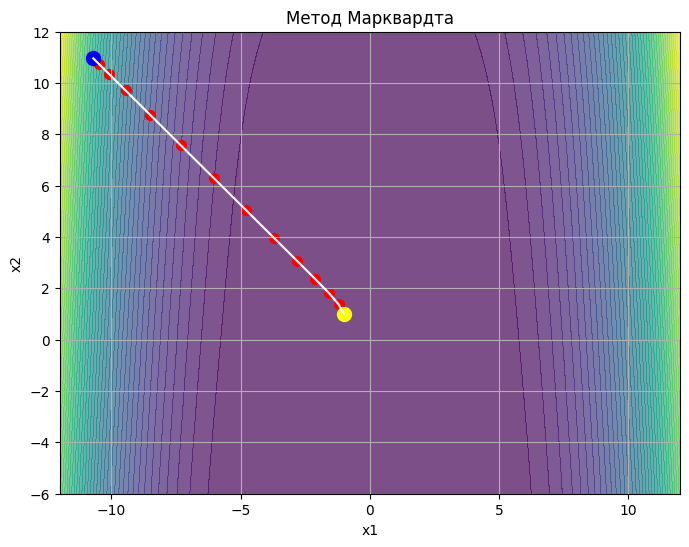

Точка минимума
x1 = -2.81
x2 = 3.13
Значение функции в этой точке: 0.00
Число итераций: 14
Число вычислений функции: 38
Число вычислений градиента функции: 19


In [14]:
def marquardt_path(x0, tol=1e-2, max_iter=100):
    x = x0.copy()
    lam = 212.0
    path = [x.copy()]
    for _ in range(max_iter):
        g = grad_f_himmelblau(x)
        if np.linalg.norm(g) < tol:
            break
        H = hess_f_himmelblau(x)
        H_lm = H + lam * np.eye(len(x))
        try:
            p = -np.linalg.solve(H_lm, g)
        except np.linalg.LinAlgError:
            lam *= 10
            continue
        x_new = x + p
        if f_himmelblau(x_new) < f_himmelblau(x):
            x = x_new
            lam *= 0.7
            path.append(x.copy())
        else:
            lam *= 2.0
    return np.array(path)

x1 = np.linspace(-12, 12, 200)
x2 = np.linspace(-6, 12, 200)
X1, X2 = np.meshgrid(x1, x2)
Z = 100 * (X1**2 + X2 - 11)**2 + (X1 + X2**2 - 7)**2

plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, Z, levels=50, cmap='viridis', alpha=0.7)

plt.plot(path_mq[:, 0], path_mq[:, 1], 'w-')
plt.scatter(path_mq[:, 0], path_mq[:, 1], c='red', s=50)
plt.scatter(x0[0], x0[1], c='yellow', s=100)
plt.scatter(path_mq[-1, 0], path_mq[-1, 1], c='blue', s=100)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Метод Марквардта")
plt.grid()
plt.show()

answer = marquardt(f_himmelblau, grad_f_himmelblau, hess_f_himmelblau, x0)
print(f"Точка минимума\nx1 = {answer[0][0]:.2f}\nx2 = {answer[0][1]:.2f}")
print(f"Значение функции в этой точке: {answer[1]:.2f}")
print(f"Число итераций: {int(answer[2])}")
print(f"Число вычислений функции: {int(answer[3])}")
print(f"Число вычислений градиента функции: {int(answer[4])}")

| Параметр | x1 | x2 | f(x1, x2) | Число итераций | Число вычислений функции | Число вычислений градиента функции |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Пакетный метод BFGS** | -2.81 | 3.13 | 0.00 | - | - | - |
| **Метод наискорейшего спуска** | -2.81 | 3.13 | 0.00 | 133 | 0 | 133 |
| **Метод Марквардта** | -2.81 | 3.13 | 0.00 | 14 | 38 | 19 |